# Data: BRFSS Survey Data in several years

Links: https://www.cdc.gov/brfss/annual_data/annual_*.html (*: 2024, 2023, 2022, ...)

---

In [1]:
import glob
import os
import re

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor
import shap

# Load

In [2]:
# ============================================================
# Dynamic Loading of Multiple Years of BRFSS Data
# Structure: data/2024/LLCP2024.XPT, data/2023/LLCP2023.XPT, ...
# ============================================================

# Find all .XPT files directly under year subdirectories
# Pattern: data/*/LLCP*.XPT
xpt_files = glob.glob("data/*/LLCP*.XPT")

print(f"Found {len(xpt_files)} XPT files:")
for f in sorted(xpt_files):
    print(f"  {f}")

if not xpt_files:
    raise FileNotFoundError("No .XPT files found in data/*/LLCP*.XPT.")

# Read and merge all files
dfs = []
for file_path in sorted(xpt_files):  # sort to ensure consistent order
    # Extract year from folder name (e.g., data/2024/LLCP2024.XPT -> 2024)
    folder = os.path.basename(os.path.dirname(file_path))  # e.g., "2024"
    year_match = re.search(r'(\d{4})', folder)
    if year_match:
        year = int(year_match.group(1))
    else:
        # Fallback: try filename
        filename = os.path.basename(file_path)
        year_match = re.search(r'(\d{4})', filename)
        if year_match:
            year = int(year_match.group(1))
        else:
            year = None
            print(f"Warning: Could not extract year from {file_path}")

    print(f"Loading {file_path} (year {year})...")
    df_year = pd.read_sas(file_path, format='xport')
    if year is not None:
        df_year['YEAR'] = year
    dfs.append(df_year)

# Concatenate all years
df = pd.concat(dfs, ignore_index=True)

print(f"Total rows: {len(df)}, columns: {len(df.columns)}")

# ============================================================
# Ensure consistent columns across years
# ============================================================
# Get intersection of columns across all dataframes
common_cols = None
for df_year in dfs:
    cols = set(df_year.columns)
    if common_cols is None:
        common_cols = cols
    else:
        common_cols = common_cols.intersection(cols)

common_cols = list(common_cols)

# Remove 'YEAR' from common columns if it was added (it's present in all years)
if 'YEAR' in common_cols:
    common_cols.remove('YEAR')

print(f"Number of common columns across all years: {len(common_cols)}")

# Keep only common columns plus YEAR (if present)
year_col = 'YEAR' if 'YEAR' in df.columns else None
cols_to_keep = common_cols + ([year_col] if year_col else [])
df = df[cols_to_keep]

print(f"Final merged dataset shape: {df.shape}")
print(f"Years included: {sorted(df['YEAR'].unique()) if year_col else 'N/A'}")

Found 7 XPT files:
  data\2018\LLCP2018.XPT
  data\2019\LLCP2019.XPT
  data\2020\LLCP2020.XPT
  data\2021\LLCP2021.XPT
  data\2022\LLCP2022.XPT
  data\2023\LLCP2023.XPT
  data\2024\LLCP2024.XPT
Loading data\2018\LLCP2018.XPT (year 2018)...
Loading data\2019\LLCP2019.XPT (year 2019)...
Loading data\2020\LLCP2020.XPT (year 2020)...
Loading data\2021\LLCP2021.XPT (year 2021)...
Loading data\2022\LLCP2022.XPT (year 2022)...
Loading data\2023\LLCP2023.XPT (year 2023)...
Loading data\2024\LLCP2024.XPT (year 2024)...
Total rows: 3032480, columns: 703
Number of common columns across all years: 124
Final merged dataset shape: (3032480, 125)
Years included: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [3]:
# Constants

feature_names = list(df.columns)
print(feature_names)

n_important_features = 20

print(df.shape)

m, n = df.shape

print(f"m: {m}")
print(f"n: {n}")


#    BRFSS uses special codes instead of leaving fields blank:
#    7/77/777/7777 = Don't know / Not sure
#    8/88/888/8888 = Refused
#    9/99/999/9999 = Missing / Unknown
# ============================================================
# Standard missing codes (will apply to all OTHER columns)
standard_missing_codes = [
    7, 8, 9,
    77, 88, 99,
    777, 888, 999,
    7777, 8888, 9999
]

# For special variables, only remove extended missing codes
# (keep 7, 8, 9, and 88 as valid)
special_missing_codes = [
    77, 99,
    777, 999,
    7777, 9999
]

# Group 1: Health days (88 = 0 days, 7/8/9 = valid days)
health_days_vars = ['PHYSHLTH', 'MENTHLTH', 'POORHLTH']

# Group 2: Counts (7/8/9 = valid counts)
count_vars = [
    'NUMADULT', 'HHADULT', 'NUMHHOL4', 'NUMPHON4', 
    'CHILDREN', '_CHLDCNT'
]

# Group 3: Age values (7/8/9 = valid ages)
age_vars = ['DIABAGE4', 'CNCRAGE', '_AGE80']

# Group 4: Drinks (7/8/9 = valid number of drinks)
drink_vars = ['AVEDRNK4', 'MAXDRNKS', 'DRNK3GE5']

# Group 5: Cigarettes (7/8/9 = valid counts)
smoke_vars = ['LCSNUMCG', 'LCSNUMC_', '_PACKDAY']

# Group 6: Income levels (7/8/9 = valid brackets)
income_vars = ['INCOME3', '_INCOMG1']

# Group 7: Education levels (7/8/9 = valid levels)
education_vars = ['EDUCA', '_EDUCAG']

# Group 8: Time/frequency variables (7/8/9 = valid years)
time_vars = [
    'CHECKUP1', 'LASTDEN4', 'HOWLONG', 'LASTSIG4', 
    'LASTSMK2', 'COLNTES1', 'SIGMTES1', 'STOLTEST', 
    'VCLNTES2'
]

# Combine all special variables
special_vars = (
    health_days_vars + count_vars + age_vars + drink_vars + 
    smoke_vars + income_vars + education_vars + time_vars
)


# ============================================================
# FIPS Code Mapping Dictionaries
# ============================================================

# Dictionary 1: FIPS Code -> State Name
fips_to_state = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas",
    6: "California", 8: "Colorado", 9: "Connecticut", 10: "Delaware",
    11: "District of Columbia", 12: "Florida", 13: "Georgia", 15: "Hawaii",
    16: "Idaho", 17: "Illinois", 18: "Indiana", 19: "Iowa",
    20: "Kansas", 21: "Kentucky", 22: "Louisiana", 23: "Maine",
    24: "Maryland", 25: "Massachusetts", 26: "Michigan", 27: "Minnesota",
    28: "Mississippi", 29: "Missouri", 30: "Montana", 31: "Nebraska",
    32: "Nevada", 33: "New Hampshire", 34: "New Jersey", 35: "New Mexico",
    36: "New York", 37: "North Carolina", 38: "North Dakota", 39: "Ohio",
    40: "Oklahoma", 41: "Oregon", 42: "Pennsylvania", 44: "Rhode Island",
    45: "South Carolina", 46: "South Dakota", 47: "Tennessee", 48: "Texas",
    49: "Utah", 50: "Vermont", 51: "Virginia", 53: "Washington",
    54: "West Virginia", 55: "Wisconsin", 56: "Wyoming",
    66: "Guam", 72: "Puerto Rico", 78: "U.S. Virgin Islands"
}


# Dictionary 2: State Name -> FIPS Code (reverse mapping)
state_to_fips = {v: k for k, v in fips_to_state.items()}

# Optional: Dictionary 3: State Abbreviation -> FIPS Code
abbr_to_fips = {
    "AL": 1, "AK": 2, "AZ": 4, "AR": 5,
    "CA": 6, "CO": 8, "CT": 9, "DE": 10,
    "DC": 11, "FL": 12, "GA": 13, "HI": 15,
    "ID": 16, "IL": 17, "IN": 18, "IA": 19,
    "KS": 20, "KY": 21, "LA": 22, "ME": 23,
    "MD": 24, "MA": 25, "MI": 26, "MN": 27,
    "MS": 28, "MO": 29, "MT": 30, "NE": 31,
    "NV": 32, "NH": 33, "NJ": 34, "NM": 35,
    "NY": 36, "NC": 37, "ND": 38, "OH": 39,
    "OK": 40, "OR": 41, "PA": 42, "RI": 44,
    "SC": 45, "SD": 46, "TN": 47, "TX": 48,
    "UT": 49, "VT": 50, "VA": 51, "WA": 53,
    "WV": 54, "WI": 55, "WY": 56,
    "GU": 66, "PR": 72, "VI": 78
}

# Optional: Dictionary 4: FIPS Code -> State Abbreviation
fips_to_abbr = {v: k for k, v in abbr_to_fips.items()}

# Filter special_vars to only include columns that exist in the dataset
special_vars_existing = [v for v in special_vars if v in df.columns]
print(f"Special variables found in dataset: {len(special_vars_existing)} of {len(special_vars)}")

print(f"\nFIPS mapping loaded: {len(fips_to_state)} states/territories")
print(f"Special variables: {len(special_vars_existing)} columns with special missing code handling")

['MARITAL', '_STATE', 'SEQNO', '_STSTR', 'HEIGHT3', 'EXERANY2', 'ASTHNOW', 'PREGNANT', 'VETERAN3', 'CSTATE1', '_CHLDCNT', '_SMOKER3', 'DIFFWALK', 'CASTHNO2', '_ASTHMS1', 'CSRVRTRN', 'RCSRLTN2', 'STOPSMK2', 'CSRVCLIN', '_DUALCOR', '_IMPRACE', 'IYEAR', 'WTKG3', 'CSRVINSR', 'CHECKUP1', 'LCSNUMCG', 'EDUCA', 'HADHYST2', 'CSRVSUM', 'PVTRESD1', 'PHYSHLTH', 'QSTLANG', '_CLLCPWT', 'HTM4', '_BMI5', '_PHYS14D', 'CNCRAGE', 'HADMAM', 'DIFFALON', 'SMOKE100', '_PSU', 'WEIGHT2', 'IDATE', 'EMPLOY1', 'MENTHLTH', 'DIFFDRES', '_AGE65YR', 'CHKHEMO3', '_URBSTAT', 'PNEUVAC4', '_RAWRAKE', 'MSCODE', 'HTIN4', '_HISPANC', 'FMONTH', 'STATERE1', '_WT2RAKE', '_AGE80', '_AGE_G', 'CAREGIV1', 'CSRVDEIN', 'QSTVER', '_DUALUSE', '_CHISPNC', 'LASTSMK2', 'SOMALE', 'TETANUS1', 'IDAY', 'SAFETIME', 'GENHLTH', 'CVDCRHD4', 'CSRVDOC1', 'CASTHDX2', 'CSRVPAIN', 'DRNK3GE5', 'RENTHOM1', '_RFBMI5', 'ASTHMA3', 'LCSFIRST', 'BLIND', 'PVTRESD3', 'DISPCODE', 'EYEEXAM1', '_PNEUMO3', 'CVDSTRK3', '_LLCPWT2', '_AGEG5YR', '_RFHLTH', 'DEAF', '_

In [4]:
def show_survey(idx):
    survey = df.iloc[idx, :]
    indices = survey.index
    
    for i in range(len(survey)):
        print(indices[i], ":", survey[i], "*" if survey[i] in standard_missing_codes else "")

show_survey(0)

MARITAL : 3.0 
_STATE : 1.0 
SEQNO : b'2018000001' 
_STSTR : 11011.0 
HEIGHT3 : 504.0 
EXERANY2 : 2.0 
ASTHNOW : nan 
PREGNANT : nan 
VETERAN3 : 2.0 
CSTATE1 : nan 
_CHLDCNT : 1.0 
_SMOKER3 : 4.0 
DIFFWALK : 1.0 
CASTHNO2 : nan 
_ASTHMS1 : 3.0 
CSRVRTRN : nan 
RCSRLTN2 : nan 
STOPSMK2 : nan 
CSRVCLIN : nan 
_DUALCOR : 0.5493244800880961 
_IMPRACE : 1.0 
IYEAR : b'2018' 
WTKG3 : 5897.0 
CSRVINSR : nan 
CHECKUP1 : 1.0 
LCSNUMCG : nan 
EDUCA : 6.0 
HADHYST2 : 1.0 
CSRVSUM : nan 
PVTRESD1 : 1.0 
PHYSHLTH : 30.0 
QSTLANG : 1.0 
_CLLCPWT : nan 
HTM4 : 163.0 
_BMI5 : 2231.0 
_PHYS14D : 3.0 
CNCRAGE : nan 
HADMAM : 1.0 
DIFFALON : 2.0 
SMOKE100 : 2.0 
_PSU : 2018000001.0 
WEIGHT2 : 130.0 
IDATE : b'01052018' 
EMPLOY1 : 2.0 
MENTHLTH : 88.0 *
DIFFDRES : 2.0 
_AGE65YR : 2.0 
CHKHEMO3 : nan 
_URBSTAT : 2.0 
PNEUVAC4 : 1.0 
_RAWRAKE : 1.0 
MSCODE : 5.0 
HTIN4 : 64.0 
_HISPANC : 2.0 
FMONTH : 1.0 
STATERE1 : 1.0 
_WT2RAKE : 65.66488343743166 
_AGE80 : 80.0 
_AGE_G : 6.0 
CAREGIV1 : nan 
CSRVDEIN : 

C:\Users\Iman\AppData\Local\Temp\ipykernel_19972\1816932553.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(indices[i], ":", survey[i], "*" if survey[i] in standard_missing_codes else "")


In [5]:
df.head()

,MARITAL,_STATE,SEQNO,_STSTR,HEIGHT3,EXERANY2,ASTHNOW,PREGNANT,VETERAN3,CSTATE1,...,_METSTAT,HHADULT,CTELENM1,HOWLONG,SHINGLE2,_MICHD,CVDINFR4,IMONTH,CCLGHOUS,YEAR
0,3.0,1.0,b'2018000001',11011.0,504.0,2.0,NaN,NaN,2.0,NaN,...,2.0,NaN,1.0,2.0,NaN,2.0,2.0,b'01',NaN,2018
1,5.0,1.0,b'2018000002',11012.0,505.0,1.0,NaN,2.0,2.0,NaN,...,1.0,NaN,1.0,2.0,NaN,2.0,2.0,b'01',NaN,2018
2,3.0,1.0,b'2018000003',11011.0,410.0,1.0,NaN,NaN,2.0,NaN,...,2.0,NaN,1.0,7.0,NaN,2.0,2.0,b'01',NaN,2018
3,2.0,1.0,b'2018000004',11011.0,510.0,1.0,NaN,NaN,2.0,NaN,...,1.0,NaN,1.0,NaN,NaN,2.0,2.0,b'01',NaN,2018
4,1.0,1.0,b'2018000005',11012.0,503.0,2.0,NaN,2.0,2.0,NaN,...,2.0,NaN,1.0,1.0,NaN,2.0,2.0,b'01',NaN,2018


### Target

#### Typical Label

| Purpose | Choice |
|:---|:---|
| General health outcomes | **`GENHLTH`** |
| Subjective wellbeing, life quality, or happiness (4-point scale: Very Satisfied to Very Dissatisfied) | **`LSATISFY`** |
| Clinical prediction or chronic disease modeling | **`DIABETE4`** |
| Mental health frequency or severity (Count of days (0-30) mental health was not good in the past month) | **`MENTHLTH`** |

In [6]:
target = "MENTHLTH" # Number of mentally unhealthy days

## Feature details

In [7]:
# ============================================================
# Dynamic Loading of SAS Label File
# Structure: data/2024/SASOUT24_LLCP.SAS, data/2023/SASOUT23_LLCP.SAS, ...
# ============================================================

# Find all SAS label files
sas_files = glob.glob("data/*/SASOUT??_LLCP.SAS")
print(f"Found {len(sas_files)} SAS label files:")
for f in sorted(sas_files):
    print(f"  {f}")

if not sas_files:
    # Fallback: try any .SAS file
    sas_files = glob.glob("data/*/*.SAS")
    print(f"Found {len(sas_files)} SAS files (fallback):")
    for f in sorted(sas_files):
        print(f"  {f}")

if not sas_files:
    raise FileNotFoundError("No SAS label file found in data/*/SASOUT??_LLCP.SAS")

# Use the most recent year (or any) for labels
# Typically variable labels are consistent across years
def extract_year_from_path(path):
    """Extract year from folder name or filename."""
    folder = os.path.basename(os.path.dirname(path))  # e.g., "2024"
    match = re.search(r'(\d{4})', folder)
    if match:
        return int(match.group(1))
    # Fallback: try filename
    filename = os.path.basename(path)
    match = re.search(r'(\d{4})', filename)
    if match:
        return int(match.group(1))
    return None

# Sort by year (descending) to get the latest
sas_files_sorted = sorted(sas_files, key=lambda x: extract_year_from_path(x) or 0, reverse=True)
chosen_sas = sas_files_sorted[0]
chosen_year = extract_year_from_path(chosen_sas)
print(f"\nUsing SAS file for labels: {chosen_sas} (year {chosen_year})")

# Read the SAS file
with open(chosen_sas, "r", encoding="latin1") as f:
    text = f.read()

# Extract LABEL section
label_pattern = r"([A-Z0-9_]+)\s*=\s*'([^']*)'"
matches = re.findall(label_pattern, text)

feature_details = {}

def pretty_label(label):
    return (
        label.replace("CALCULATED VARIABLE", "")
             .replace("COMPUTED", "")
             .strip()
             .title()
    )

feature_details = {
                    "YEAR": 
                        {"name": pretty_label("Dataset Year"), 
                         "desc": "Dataset Year".capitalize()}
                  }

for var, label in matches:
    feature_details[var] = {
        "name": pretty_label(label),
        "desc": label.capitalize()
    }

print(f"Variables extracted: {len(feature_details)}")

Found 7 SAS label files:
  data\2018\SASOUT18_LLCP.SAS
  data\2019\SASOUT19_LLCP.SAS
  data\2020\SASOUT20_LLCP.SAS
  data\2021\SASOUT21_LLCP.SAS
  data\2022\SASOUT22_LLCP.SAS
  data\2023\SASOUT23_LLCP.SAS
  data\2024\SASOUT24_LLCP.SAS

Using SAS file for labels: data\2024\SASOUT24_LLCP.SAS (year 2024)
Variables extracted: 302


In [8]:
feature_details["GENHLTH"]

{'name': 'General Health', 'desc': 'General health'}

---

# Preprocessing

In [9]:
# ============================================================
# 1. Decode byte columns
# ============================================================
for c in df.columns:
    if df[c].dtype == object:
        try:
            df[c] = df[c].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
        except:
            pass

# ============================================================
# 2. Remove BRFSS Missing Codes
# ============================================================

# Apply standard codes to all columns
for col in df.columns:
    if col not in special_vars:
        df[col] = df[col].replace(standard_missing_codes, np.nan)

# Apply special handling to health days (convert 88 to 0)
for col in health_days_vars:
    if col in df.columns:
        df[col] = df[col].replace(special_missing_codes, np.nan)
        df[col] = df[col].replace(88, 0)  # 88 = 0 days
        # 7, 8, 9 remain as 7, 8, 9 days

# Apply special handling to other special variables
for col in special_vars:
    if col not in health_days_vars:
        if col in df.columns:
            df[col] = df[col].replace(special_missing_codes, np.nan)
            # 7, 8, 9, 88 remain as valid values

# ============================================================
# 3. Drop rows missing target
# ============================================================

df = df.dropna(subset=[target])

# ============================================================
# 4. Remove ID Columns
# ============================================================
drop_cols = [
    target,            # Target shouldn't be in the features
    "SEQNO",           # Unique identifier
    "_PSU",            # Primary Sampling Unit (for survey design)
    "_STSTR",          # Stratification variable (for survey design)
    "IDATE",           # Interview date (may not be needed)
    "IMONTH",          # Interview month (may not be needed)
    "IDAY",            # Interview day (may not be needed)
    "IYEAR"            # Interview year (may not be needed)
]

X = df.drop(columns=drop_cols, errors="ignore")

# ============================================================
# 5. Remove leakage columns
#    These are CDC-derived variables based directly on the target
# ============================================================
if target == "MENTHLTH":
    leakage = ["_MENT14D", "POORHLTH"] # "PHYSHLTH" ?
elif target == "PHYSHLTH":
    leakage = ["_PHYS14D"]
elif target == "GENHLTH":
    leakage = ["_RFHLTH"]
elif target == "LSATISFY":
    leakage = []  # No known derived variable for LSATISFY
else:
    leakage = []

X = X.drop(columns=leakage, errors="ignore")

# Store y (target)
y = df[target]

# ============================================================
# 6. Remove Features with >50% Missing
# ============================================================
missing_pct = X.isnull().mean()
X = X.loc[:, missing_pct < 0.50]

print(f"Remaining Features: {len(X.columns)}")

# ============================================================
# 7. Convert Categoricals to Integers
# ============================================================
for col in X.columns:
    if X[col].dtype == object:
        X[col] = pd.factorize(X[col])[0]

# ============================================================
# 8. Impute Missing Values (Median Strategy)
# ============================================================
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# ============================================================
# 9. (Optional) Handle Infinite Values
# ============================================================
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    columns=X.columns
)

# ============================================================
# 10. BMI Scaling
# ============================================================
# The _BMI5 variable is stored as an integer (e.g., 2500, 3015).
# Divide by 100 to convert to standard BMI format (e.g., 25.0, 30.15).

if '_BMI5' in df.columns:
    df['BMI'] = df['_BMI5'] / 100.0
    
    print(f"BMI Conversion Complete. Example: _BMI5 = 2500 -> BMI = 25.0")
    print(f"BMI Column Summary:")
    print(df['BMI'].describe())

# ============================================================
# 11. (Optional) Convert Target if Needed
# ============================================================
# For binary classification targets (e.g., DIABETE4):
# if target == "DIABETE4":
#     # Convert to binary: 1 = Yes, 0 = No/Pre-diabetic/etc.
#     y = y.apply(lambda x: 1 if x == 1 else 0)

# For ordinal targets (e.g., GENHLTH):
# Keep as is (1-5 scale)

Remaining Features: 68
BMI Conversion Complete. Example: _BMI5 = 2500 -> BMI = 25.0
BMI Column Summary:
count    2.693609e+06
mean     2.843870e+01
std      6.486907e+00
min      1.200000e+01
25%      2.403000e+01
50%      2.737000e+01
75%      3.158000e+01
max      9.984000e+01
Name: BMI, dtype: float64


C:\Users\Iman\AppData\Local\Temp\ipykernel_19972\2823531486.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['BMI'] = df['_BMI5'] / 100.0


In [10]:
print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")

Final X shape: (2975511, 68)
Final y shape: (2975511,)
Target distribution:
MENTHLTH
0.0     1875267
1.0       95587
2.0      157358
3.0       99096
4.0       51005
5.0      128501
6.0       14568
7.0       50298
8.0       10815
9.0        1879
10.0      98113
11.0        815
12.0       7612
13.0       1091
14.0      18256
15.0      91702
16.0       1717
17.0       1454
18.0       2020
19.0        287
20.0      55996
21.0       3525
22.0       1089
23.0        698
24.0        776
25.0      19631
26.0        729
27.0       1433
28.0       5525
29.0       3001
30.0     175667
Name: count, dtype: int64


---

# Feature Importance


MAE : 4.318018037072536
R2  : 0.2840501454716017

Top 20 Features
     feature  importance
54    DECIDE    0.361651
18  _PHYS14D    0.114564
33    _AGE_G    0.074861
14  PHYSHLTH    0.053785
19  DIFFALON    0.043253
46  _AGEG5YR    0.042283
47   _RFHLTH    0.034667
24  _AGE65YR    0.027116
36   GENHLTH    0.022579
15   QSTLANG    0.021623
32    _AGE80    0.015161
38  RENTHOM1    0.015146
55  _LTASTH1    0.014259
40   ASTHMA3    0.013795
50  _RFSMOK3    0.011367
0    MARITAL    0.008942
20  SMOKE100    0.007740
7   _SMOKER3    0.007511
10  _IMPRACE    0.005251
56  _TOTINDA    0.005107


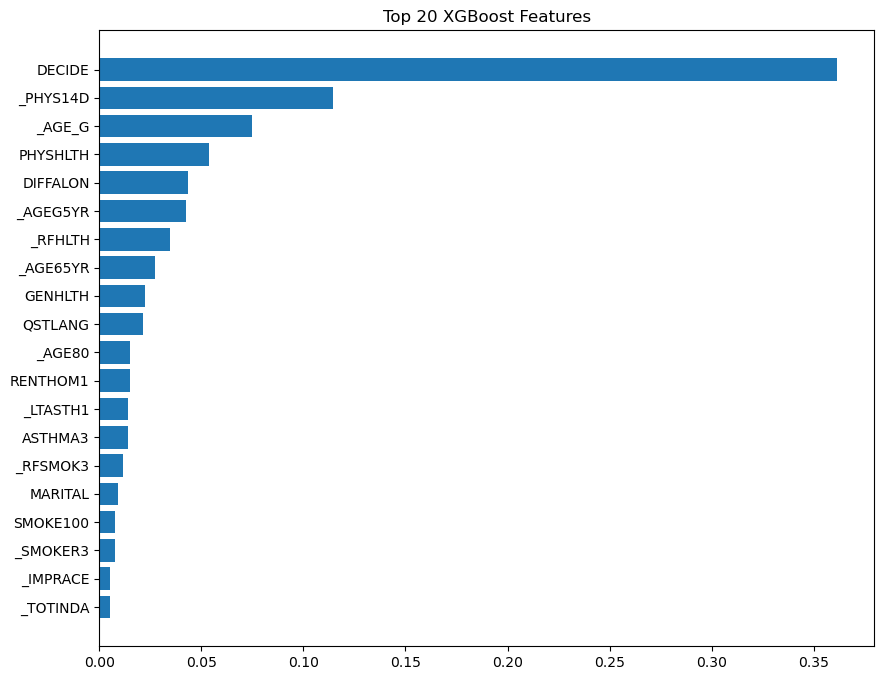

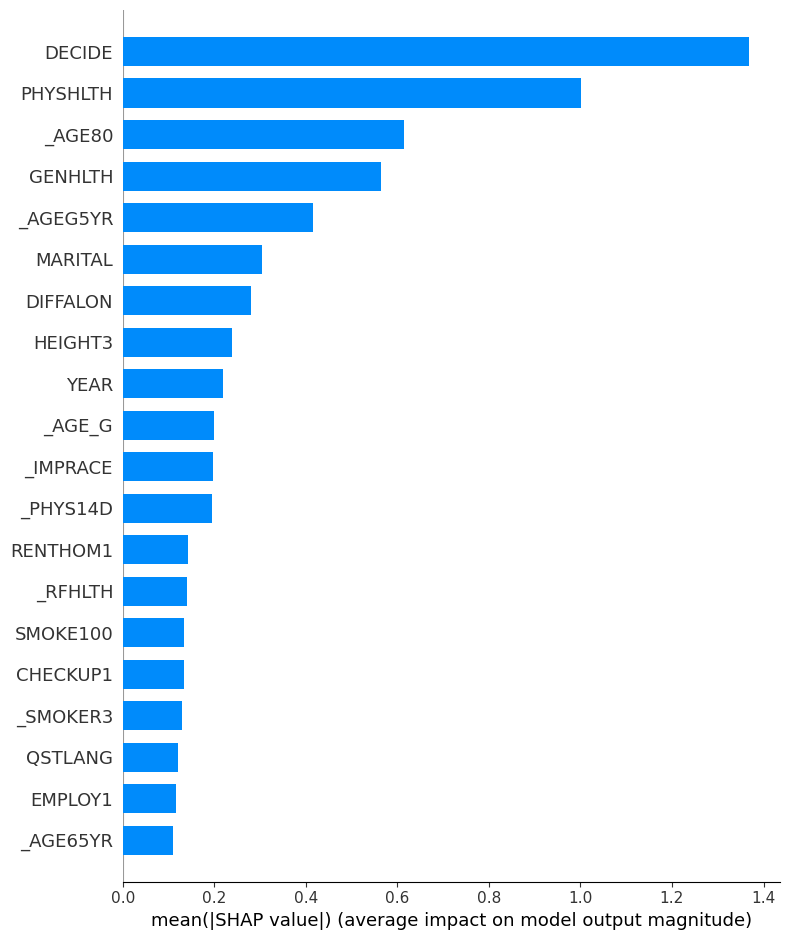

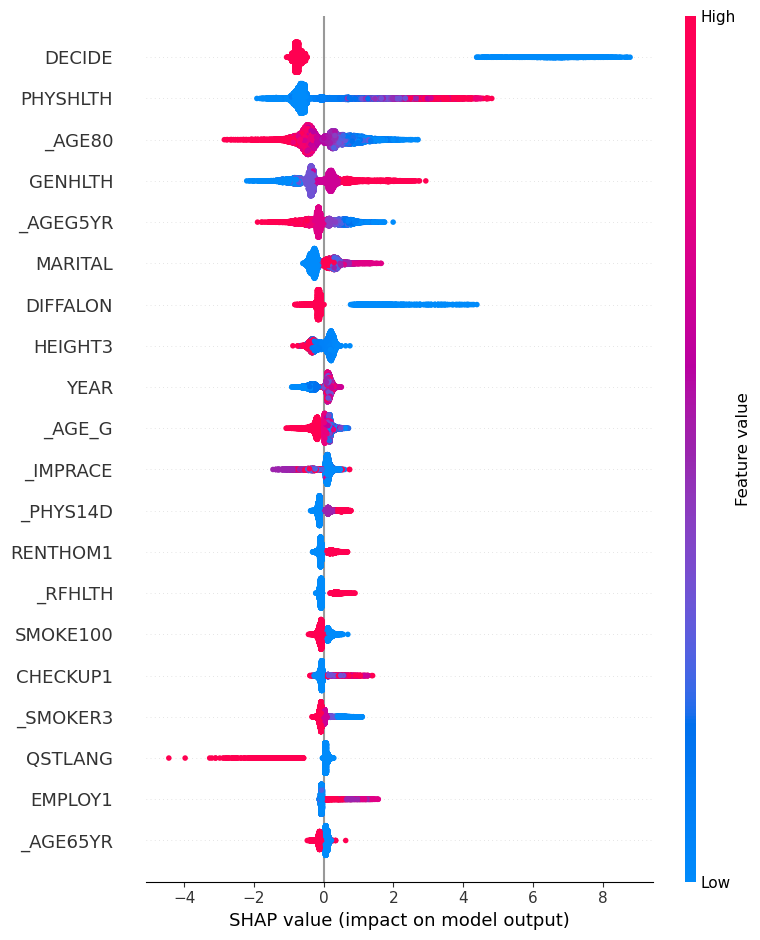


Saved: BRFSS_feature_importance.csv

     feature  shap_importance
54    DECIDE         1.367645
14  PHYSHLTH         1.001829
32    _AGE80         0.615454
36   GENHLTH         0.563618
46  _AGEG5YR         0.416163
0    MARITAL         0.304102
19  DIFFALON         0.280321
2    HEIGHT3         0.238732
67      YEAR         0.218696
33    _AGE_G         0.199404
10  _IMPRACE         0.197973
18  _PHYS14D         0.194609
38  RENTHOM1         0.142220
47   _RFHLTH         0.141092
20  SMOKE100         0.133401
12  CHECKUP1         0.133036
7   _SMOKER3         0.130177
15   QSTLANG         0.119841
22   EMPLOY1         0.116441
24  _AGE65YR         0.109215


In [11]:
# ============================================================
# BRFSS Feature Importance using XGBoost
# Target: MENTHLTH
# ============================================================

# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================================
# Train XGBoost
# ============================================================

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

# ============================================================
# Evaluate
# ============================================================

preds = model.predict(
    X_test
)

print()
print("MAE :", mean_absolute_error(y_test, preds))
print("R2  :", r2_score(y_test, preds))

# ============================================================
# XGBoost Native Importance
# ============================================================

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print()
print(f"Top {n_important_features} Features")
print(
    importance.head(n_important_features)
)

# ============================================================
# Plot Top Features
# ============================================================

top = importance.head(n_important_features)

plt.figure(figsize=(10,8))

plt.barh(
    top["feature"],
    top["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    f"Top {n_important_features} XGBoost Features"
)

plt.show()

# ============================================================
# SHAP Explainability
# ============================================================

explainer = shap.TreeExplainer(
    model
)

# use sample for speed

sample = X_train.sample(
    min(10000, len(X_train)),
    random_state=42
)

shap_values = explainer.shap_values(
    sample
)

# ============================================================
# SHAP Global Importance
# ============================================================

shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar"
)

# ============================================================
# SHAP Detailed Summary
# ============================================================

shap.summary_plot(
    shap_values,
    sample
)

# ============================================================
# Save Ranked Features
# ============================================================

shap_importance = pd.DataFrame({

    "feature": sample.columns,

    "shap_importance":
        np.abs(shap_values).mean(axis=0)

})

shap_importance = shap_importance.sort_values(
    "shap_importance",
    ascending=False
)

shap_importance.to_csv(
    "BRFSS_feature_importance.csv",
    index=False
)

print()
print("Saved: BRFSS_feature_importance.csv")

print()
print(shap_importance.head(n_important_features))

In [12]:
xgb_important_feature_names = list(importance.feature[:n_important_features])
print("XGBoost")
for i, feature_name in enumerate(xgb_important_feature_names, 1):
    print(i, "\t", feature_name, "\t", feature_details[feature_name]["desc"])

XGBoost
1 	 DECIDE 	 Difficulty concentrating or remembering
2 	 _PHYS14D 	 Computed physical health status
3 	 _AGE_G 	 Imputed age in six groups
4 	 PHYSHLTH 	 Number of days physical health not good
5 	 DIFFALON 	 Difficulty doing errands alone
6 	 _AGEG5YR 	 Reported age in five-year age categories calculated variable
7 	 _RFHLTH 	 Adults with good or better health
8 	 _AGE65YR 	 Reported age in two age groups calculated variable
9 	 GENHLTH 	 General health
10 	 QSTLANG 	 Language identifier
11 	 _AGE80 	 Imputed age value collapsed above 80
12 	 RENTHOM1 	 Own or rent home
13 	 _LTASTH1 	 Lifetime asthma calculated variable
14 	 ASTHMA3 	 Ever told had asthma
15 	 _RFSMOK3 	 Current smoking calculated variable
16 	 MARITAL 	 Marital status
17 	 SMOKE100 	 Smoked at least 100 cigarettes
18 	 _SMOKER3 	 Computed smoking status
19 	 _IMPRACE 	 Imputed race/ethnicity value
20 	 _TOTINDA 	 Leisure time physical activity calculated variable


In [13]:
shap_important_feature_names = list(shap_importance.feature[:n_important_features])
print("SHAP")
for i, feature_name in enumerate(shap_important_feature_names, 1):
    print(i, "\t", feature_name, "\t", feature_details[feature_name]["desc"])

SHAP
1 	 DECIDE 	 Difficulty concentrating or remembering
2 	 PHYSHLTH 	 Number of days physical health not good
3 	 _AGE80 	 Imputed age value collapsed above 80
4 	 GENHLTH 	 General health
5 	 _AGEG5YR 	 Reported age in five-year age categories calculated variable
6 	 MARITAL 	 Marital status
7 	 DIFFALON 	 Difficulty doing errands alone
8 	 HEIGHT3 	 Reported height in feet and inches
9 	 YEAR 	 Dataset year
10 	 _AGE_G 	 Imputed age in six groups
11 	 _IMPRACE 	 Imputed race/ethnicity value
12 	 _PHYS14D 	 Computed physical health status
13 	 RENTHOM1 	 Own or rent home
14 	 _RFHLTH 	 Adults with good or better health
15 	 SMOKE100 	 Smoked at least 100 cigarettes
16 	 CHECKUP1 	 Length of time since last routine checkup
17 	 _SMOKER3 	 Computed smoking status
18 	 QSTLANG 	 Language identifier
19 	 EMPLOY1 	 Employment status
20 	 _AGE65YR 	 Reported age in two age groups calculated variable


In [14]:
len(set(shap_important_feature_names).intersection(set(xgb_important_feature_names)))

16

In [15]:
set(shap_important_feature_names).difference(set(xgb_important_feature_names))

{'CHECKUP1', 'EMPLOY1', 'HEIGHT3', 'YEAR'}

In [16]:
set(xgb_important_feature_names).difference(set(shap_important_feature_names))

{'ASTHMA3', '_LTASTH1', '_RFSMOK3', '_TOTINDA'}

---

# Data Visualization

In [ ]:
# Create plots directory if it doesn't exist
os.makedirs("plots", exist_ok=True)

# ============================================================
# 1. Target Distribution (MENTHLTH)
# ============================================================
fig1 = px.histogram(
    y,
    nbins=30,
    title="Distribution of Mentally Unhealthy Days (MENTHLTH)",
    labels={"value": "Number of Days", "count": "Frequency"},
    color_discrete_sequence=["#2E86AB"]
)
fig1.add_vline(x=14, line_dash="dash", line_color="red", 
               annotation_text="Clinical Threshold (14+ days)")
fig1.update_layout(
    xaxis_title="Number of Mentally Unhealthy Days (0-30)",
    yaxis_title="Number of Respondents",
    showlegend=False
)
fig1.write_html("plots/1_target_distribution.html")
fig1.show()

# ============================================================
# 2. Top 20 SHAP Features - Waterfall Summary
# ============================================================
fig2 = px.bar(
    shap_importance.head(20),
    x="shap_importance",
    y="feature",
    orientation='h',
    title="Top 20 Features by SHAP Importance",
    labels={"shap_importance": "Mean |SHAP Value|", "feature": ""},
    color="shap_importance",
    color_continuous_scale="Blues"
)
fig2.update_layout(
    xaxis_title="Mean |SHAP Value| (Impact on Predictions)",
    yaxis_title="Feature",
    height=600,
    showlegend=False
)
fig2.write_html("plots/2_top_shap_features.html")
fig2.show()

# ============================================================
# 3. Correlation Heatmap of Top Features
# ============================================================
top_features = shap_importance.head(15)["feature"].tolist()
corr_data = X[top_features].copy()
corr_data[target] = y.values  # if y is separate
corr_matrix = corr_data.corr()

fig3 = px.imshow(
    corr_matrix,
    text_auto=".2f",
    aspect="auto",
    title="Correlation Heatmap: Top Features vs Target",
    labels={"color": "Correlation", "variable": "", "y": ""},
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1
)
fig3.update_layout(
    height=700,
    width=800
)
fig3.write_html("plots/3_correlation_heatmap.html")
fig3.show()

# ============================================================
# 4. Scatter: ADDEPEV3 (Depression) vs MENTHLTH
# ============================================================
if "ADDEPEV3" in X:
    fig4 = px.box(
        pd.DataFrame({target: y, "ADDEPEV3": X["ADDEPEV3"]}),
        x="ADDEPEV3",
        y=target,
        color="ADDEPEV3",
        title="Mental Health Days by Depressive Disorder Diagnosis",
        labels={"ADDEPEV3": "Ever Told Depressive Disorder", target: "Mentally Unhealthy Days"},
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    fig4.update_layout(
        xaxis_title="Ever Told Depressive Disorder (1=Yes, 2=No)",
        yaxis_title="Number of Mentally Unhealthy Days",
        showlegend=False
    )
    fig4.write_html("plots/4_depression_vs_menthealth.html")
    fig4.show()

# ============================================================
# 5. Scatter: GENHLTH (General Health) vs MENTHLTH
# ============================================================
genhlth_labels = {1: "Excellent", 2: "Very Good", 3: "Good", 4: "Fair", 5: "Poor"}
df_plot = pd.DataFrame({
    target: y,
    "GENHLTH": X["GENHLTH"]
})
df_plot["GENHLTH_LABEL"] = df_plot["GENHLTH"].map(genhlth_labels)

fig5 = px.box(
    df_plot,
    x="GENHLTH_LABEL",
    y=target,
    title="Mental Health Days by Self-Reported General Health",
    labels={"GENHLTH_LABEL": "General Health Status", target: "Mentally Unhealthy Days"},
    color="GENHLTH_LABEL",
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig5.update_layout(
    xaxis_title="General Health Status",
    yaxis_title="Number of Mentally Unhealthy Days",
    showlegend=False
)
fig5.write_html("plots/5_genhlth_vs_menthealth.html")
fig5.show()

# ============================================================
# 6. PHYSHLTH vs MENTHLTH Scatter
# ============================================================
df_scatter = pd.DataFrame({
    target: y,
    "PHYSHLTH": X["PHYSHLTH"]
})
# Sample for performance
df_scatter_sample = df_scatter.sample(min(10000, len(df_scatter)), random_state=42)

fig6 = px.scatter(
    df_scatter_sample,
    x="PHYSHLTH",
    y=target,
    title="Physical Health Days vs Mental Health Days",
    labels={"PHYSHLTH": "Days Physical Health Not Good", target: "Days Mental Health Not Good"},
    opacity=0.5,
    trendline="ols",
    color_discrete_sequence=["#2E86AB"]
)
fig6.update_layout(
    xaxis_title="Days Physical Health Not Good (0-30)",
    yaxis_title="Days Mental Health Not Good (0-30)"
)
fig6.write_html("plots/6_physhlth_vs_menthlth.html")
fig6.show()

# ============================================================
# 7. Age Distribution of Mental Health Days
# ============================================================
age_labels = {
    1: "18-24", 2: "25-34", 3: "35-44", 
    4: "45-54", 5: "55-64", 6: "65+"
}
df_age = pd.DataFrame({
    target: y,
    "AGE_G": X["_AGE_G"]
})
df_age["AGE_GROUP"] = df_age["AGE_G"].map(age_labels)

fig7 = px.box(
    df_age,
    x="AGE_GROUP",
    y=target,
    title="Mental Health Days by Age Group",
    labels={"AGE_GROUP": "Age Group", target: "Mentally Unhealthy Days"},
    color="AGE_GROUP",
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig7.update_layout(
    xaxis_title="Age Group",
    yaxis_title="Number of Mentally Unhealthy Days",
    showlegend=False
)
fig7.write_html("plots/7_age_vs_menthealth.html")
fig7.show()

# ============================================================
# 8. Sex Comparison of Mental Health Days
# ============================================================
if "SEX" in X:
    sex_labels = {1: "Male", 2: "Female"}
    df_sex = pd.DataFrame({
        target: y,
        "SEX": X["_SEX"]
    })
    df_sex["SEX_LABEL"] = df_sex["SEX"].map(sex_labels)
    
    fig8 = px.box(
        df_sex,
        x="SEX_LABEL",
        y=target,
        title="Mental Health Days by Sex",
        labels={"SEX_LABEL": "Sex", target: "Mentally Unhealthy Days"},
        color="SEX_LABEL",
        color_discrete_sequence=["#1F77B4", "#FF7F0E"]
    )
    fig8.update_layout(
        xaxis_title="Sex",
        yaxis_title="Number of Mentally Unhealthy Days",
        showlegend=False
    )
    fig8.write_html("plots/8_sex_vs_menthealth.html")
    fig8.show()

# ============================================================
# 9. DECIDE (Cognitive Difficulty) vs MENTHLTH
# ============================================================
decide_labels = {1: "Yes", 2: "No"}
df_decide = pd.DataFrame({
    target: y,
    "DECIDE": X["DECIDE"]
})
df_decide["DECIDE_LABEL"] = df_decide["DECIDE"].map(decide_labels)

fig9 = px.box(
    df_decide,
    x="DECIDE_LABEL",
    y=target,
    title="Mental Health Days by Cognitive Difficulty",
    labels={"DECIDE_LABEL": "Difficulty Concentrating or Remembering", target: "Mentally Unhealthy Days"},
    color="DECIDE_LABEL",
    color_discrete_sequence=["#D62728", "#2CA02C"]
)
fig9.update_layout(
    xaxis_title="Difficulty Concentrating or Remembering",
    yaxis_title="Number of Mentally Unhealthy Days",
    showlegend=False
)
fig9.write_html("plots/9_decide_vs_menthealth.html")
fig9.show()

# ============================================================
# 10. State-wise Mental Health Days (Geographic Analysis)
# ============================================================
if "_STATE" in X.columns:
    state_labels = {1: "AL", 2: "AK", 4: "AZ", 5: "AR", 6: "CA", 8: "CO", 
                    9: "CT", 10: "DE", 11: "DC", 12: "FL", 13: "GA", 15: "HI",
                    16: "ID", 17: "IL", 18: "IN", 19: "IA", 20: "KS", 21: "KY",
                    22: "LA", 23: "ME", 24: "MD", 25: "MA", 26: "MI", 27: "MN",
                    28: "MS", 29: "MO", 30: "MT", 31: "NE", 32: "NV", 33: "NH",
                    34: "NJ", 35: "NM", 36: "NY", 37: "NC", 38: "ND", 39: "OH",
                    40: "OK", 41: "OR", 42: "PA", 44: "RI", 45: "SC", 46: "SD",
                    47: "TN", 48: "TX", 49: "UT", 50: "VT", 51: "VA", 53: "WA",
                    54: "WV", 55: "WI", 56: "WY", 66: "GU", 72: "PR", 78: "VI"}
    
    df_state = pd.DataFrame({
        target: y,
        "_STATE": X["_STATE"]
    })
    df_state["STATE_ABBR"] = df_state["_STATE"].map(state_labels)
    
    # Calculate mean mental health days by state
    state_means = df_state.groupby("STATE_ABBR")[target].mean().sort_values().reset_index()
    
    fig10 = px.bar(
        state_means,
        x="STATE_ABBR",
        y=target,
        title="Average Mental Health Days by State",
        labels={"STATE_ABBR": "State", target: "Mean Mentally Unhealthy Days"},
        color=target,
        color_continuous_scale="Reds"
    )
    fig10.update_layout(
        xaxis_title="State",
        yaxis_title="Mean Number of Mentally Unhealthy Days",
        showlegend=False
    )
    fig10.write_html("plots/10_state_vs_menthealth.html")
    fig10.show()

# ============================================================
# 11. MEDCOST1 (Affordability) vs MENTHLTH
# ============================================================
medcost_labels = {1: "Yes", 2: "No"}
df_medcost = pd.DataFrame({
    target: y,
    "MEDCOST1": X["MEDCOST1"]
})
df_medcost["MEDCOST_LABEL"] = df_medcost["MEDCOST1"].map(medcost_labels)

fig11 = px.box(
    df_medcost,
    x="MEDCOST_LABEL",
    y=target,
    title="Mental Health Days by Ability to Afford Doctor",
    labels={"MEDCOST_LABEL": "Could Not Afford to See Doctor", target: "Mentally Unhealthy Days"},
    color="MEDCOST_LABEL",
    color_discrete_sequence=["#9467BD", "#8C564B"]
)
fig11.update_layout(
    xaxis_title="Could Not Afford to See Doctor (1=Yes, 2=No)",
    yaxis_title="Number of Mentally Unhealthy Days",
    showlegend=False
)
fig11.write_html("plots/11_medcost_vs_menthealth.html")
fig11.show()

# ============================================================
# 12. Interactive Dashboard: Top Feature Relationships
# ============================================================
# Create a 2x2 subplot dashboard
fig12 = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "ADDEPEV3 (Depression) vs MENTHLTH",
        "DECIDE (Cognitive) vs MENTHLTH",
        "PHYSHLTH vs MENTHLTH",
        "GENHLTH vs MENTHLTH"
    )
)

# Plot 1: ADDEPEV3
fig12.add_trace(
    go.Box(y=y, x=X["ADDEPEV3"], name="ADDEPEV3", showlegend=False),
    row=1, col=1
)

# Plot 2: DECIDE
fig12.add_trace(
    go.Box(y=y, x=X["DECIDE"], name="DECIDE", showlegend=False),
    row=1, col=2
)

# Plot 3: PHYSHLTH (scatter, sampled)
sample_idx = np.random.choice(len(X), min(5000, len(X)), replace=False)
fig12.add_trace(
    go.Scatter(
        x=X["PHYSHLTH"].iloc[sample_idx],
        y=y.iloc[sample_idx],
        mode="markers",
        marker=dict(size=3, opacity=0.5),
        name="PHYSHLTH",
        showlegend=False
    ),
    row=2, col=1
)

# Plot 4: GENHLTH
fig12.add_trace(
    go.Box(y=y, x=X["GENHLTH"], name="GENHLTH", showlegend=False),
    row=2, col=2
)

fig12.update_layout(
    height=800,
    width=1000,
    title_text="Interactive Dashboard: Key Features vs Mental Health Days",
    showlegend=False
)

fig12.update_xaxes(title_text="ADDEPEV3", row=1, col=1)
fig12.update_xaxes(title_text="DECIDE", row=1, col=2)
fig12.update_xaxes(title_text="PHYSHLTH", row=2, col=1)
fig12.update_xaxes(title_text="GENHLTH", row=2, col=2)

fig12.update_yaxes(title_text="MENTHLTH", row=1, col=1)
fig12.update_yaxes(title_text="MENTHLTH", row=1, col=2)
fig12.update_yaxes(title_text="MENTHLTH", row=2, col=1)
fig12.update_yaxes(title_text="MENTHLTH", row=2, col=2)

fig12.write_html("plots/12_dashboard_key_features.html")
fig12.show()

# ============================================================
# 13. Scatter: DECIDE vs MENTHLTH
# ============================================================
if "DECIDE" in X:
    fig13 = px.box(
        pd.DataFrame({target: y, "DECIDE": X["DECIDE"]}),
        x="DECIDE",
        y=target,
        color="DECIDE",
        title="Mental Health Days by Decide",
        labels={"DECIDE": "Difficulty Concentrating Or Remembering", target: "Mentally Unhealthy Days"},
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    fig13.update_layout(
        xaxis_title="Difficulty Concentrating Or Remembering (1=Yes, 2=No)",
        yaxis_title="Number of Mentally Unhealthy Days",
        showlegend=False
    )
    fig13.write_html("plots/13_decide_vs_menthealth.html")
    fig13.show()

    
print("All plots saved to /plots directory!")

---